# CNN using Pytorch for Cancer detection

In [1]:
# necessary packages
import os
import torch
from torch.utils.data import random_split
from torch.utils.data import DataLoader, Dataset, Subset, SubsetRandomSampler
from torchvision import datasets, transforms, models 
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
import random

torch.set_default_dtype(torch.float32)

# The rest of your code...

Lungenkrebs Datensatz in das System Laden

In [2]:
lung_dataset = '../lung_colon_image_set/lung_image_sets'
colon_dataset = '../lung_colon_image_set/colon_image_sets'
if not os.path.exists(lung_dataset):
    raise FileNotFoundError(f"Dataset path {lung_dataset} does not exist!")
if not os.path.exists(colon_dataset):
    raise FileNotFoundError(f"Dataset path {colon_dataset} does not exist!")

lung_classes=sorted(os.listdir(lung_dataset))
colon_classes=sorted(os.listdir(colon_dataset))

print(f"Classes found: {lung_classes} and {colon_classes}")

all_classes = sorted(set(lung_classes + colon_classes))
print(f"Combined classes: {all_classes}")


Classes found: ['lung_aca', 'lung_n', 'lung_scc'] and ['colon_aca', 'colon_n']
Combined classes: ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']


## Bilder in Train, Test und Validierungssplits aufteilen

Teilt die Bilder in drei Kategorien ein
- 80% sind Trainingsdaten
- 10% sind Testdaten
- 10% sind Validierungsdaten

In [3]:
def prepare_splits(datadirs, split_ratios=(0.8, 0.1, 0.1)):
    all_data = {}
    for datadir in datadirs:
        for cls in sorted(os.listdir(datadir)):
            class_dir = os.path.join(datadir, cls)
            if os.path.isdir(class_dir):
                all_data.setdefault(cls, []).extend(
                    os.path.join(class_dir,fname) for fname in os.listdir(class_dir)
                )
    
    splits = {'train': [], 'val': [], 'test': []}
    
    for cls, files in all_data.items():
        train_files, temp_files = train_test_split(files, test_size=(1 - split_ratios[0]), random_state=42)
        
        val_files, test_files = train_test_split(temp_files, test_size=split_ratios[2]/(split_ratios[1] + split_ratios[2]), random_state=42)
        
        splits['train'].extend(train_files)
        splits['val'].extend(val_files)
        splits['test'].extend(test_files)
        
    return splits

dataset_dirs = [lung_dataset, colon_dataset]
data_splits = prepare_splits(dataset_dirs)

print(f"Training samples: {len(data_splits['train'])}")
print(f"Validation samples: {len(data_splits['val'])}")
print(f"Testing samples: {len(data_splits['test'])}")

Training samples: 20000
Validation samples: 2500
Testing samples: 2500


In [4]:
class CombinedCancerDataset(Dataset):
    def __init__(self, file_paths, all_classes, transform=None):
        self.file_paths = file_paths
        self.all_classes = all_classes
        self.labels = [all_classes.index(os.path.basename(os.path.dirname(fp))) for fp in file_paths]
        self.transform = transform
        
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(random.randint(-45, 45)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])    

# Datasets
train_dataset = CombinedCancerDataset(data_splits['train'], all_classes, transform=transform)
val_dataset = CombinedCancerDataset(data_splits['val'], all_classes, transform=transform)
test_dataset = CombinedCancerDataset(data_splits['test'], all_classes, transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)



##### CNN Klasse mit 6 convolutional Layer, 1 Pooling Layer, 3 batch normalizer und 2 Fully connected layers

In [7]:
class CNN_Model(nn.Module):
    def __init__(self, num_classes=5):
        super(CNN_Model, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding='same')
        self.pool = nn.MaxPool2d(2, 2)
        # self.pool = nn.MeanPool2d(2, 2)
        # self.pool = nn.RandomPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 32, 3, padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, 3, padding='same')
        self.conv4 = nn.Conv2d(64, 64, 3, padding='same')
        self.bn2 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, 3, padding='same')
        self.conv6 = nn.Conv2d(128, 128, 3, padding='same')
        self.bn3 = nn.BatchNorm2d(128)
        
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.bn1(x)
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        x = F.relu(self.conv4(x))
        x = self.pool(x)
        x = self.bn2(x)
        x = F.relu(self.conv5(x))
        x = self.pool(x)
        x = F.relu(self.conv6(x))
        x = self.pool(x)
        x = self.bn3(x)
        
        #print(x.size())
        #print(f"Shape after conv layers: {x.shape}")
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
        

In [ ]:
# grad cam with bounding box


## Training des Modells

Training des Modells auf einem Trainingsdatensatz und Validierung durch einen Validierungsdatensatz über eine bestimmte Anzahl von Epochen. Verwendung von Adam-Optimierer und die Kreuzentropie-Verlustfunktion. Die Funktion verfolgt und speichert die Trainingsverluste, Validierungsverluste und Validierungsgenauigkeit für jede Epoche.

#### Ablauf
- Initialisiert den Adam-Optimierer und die Kreuzentropie-Verlustfunktion
- Verschiebt Modell auf das angegebene Gerät (CPU oder GPU)
- Initialisiert Listen zur Speicherung der Verluste und Genauigkeit
- **Trainingsschritte pro Epoche**

    - Daten auf das Gerät verschieben
    - Gradienten zurücksetzen
    - Vorwärtsdurchlauf, Parameter aktualieren
    - Verlust akkumulieren
    - Durchschnittliche Trainingsverluste berechnen

- **Validierung pro Epoche**

    - Modell in Evaluierungsmodus setzen, verlust und Zähler initialisieren
    - Für jede Charge:
        - Daten auf Gerät schieben
        - Vorwärtsdurchlauf, Verlust berechnen
        - Verlust akkumulieren
        - Vorhersagen analysieren, Genauigkeit berechnen
    - Durchschnittlichen Validierungsverlust und -genauigkeit berechnen und ausgeben
    
- Gibt die Listen der Trainingsverluste, Validierungsverluste und Validierungsgenauigkeiten zurück


In [8]:
def train_model(model, train_loader, val_loader, num_epochs=5, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.to(device)
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)
    
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")
    

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        epoch_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct / total
        val_losses.append (epoch_val_loss)
        val_accuracies.append(val_accuracy)
                
        val_accuracy = 100 * correct / total
        print(f"Validation Loss: {val_loss/len(val_loader)}, Validation Accuracy: {val_accuracy}")
    
    return train_losses, val_losses, val_accuracies

### GPU für Training verwenden

- Anstatt von Cuda muss man bei Mac Mps verwenden also:

```python 
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
```

```python 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
```

In [9]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"Using device: {device}")

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Cuda availabel: {torch.cuda.is_availlable()}")
# print(f"Using device: {device}")

if __name__ == "__main__":
    model = CNN_Model(num_classes=len(all_classes)).to(device)
    train_losses, val_losses, val_accuracies = train_model(model, train_loader, val_loader)

    print("Training abgeschlossen.")

MPS available: True
Using device: mps
Epoch 1, Loss: 0.3347193392202258
Validation Loss: 0.7979814908167853, Validation Accuracy: 77.56
Epoch 2, Loss: 0.1937363816190511
Validation Loss: 0.10917640115530379, Validation Accuracy: 96.24
Epoch 3, Loss: 0.128617608049931
Validation Loss: 0.1914863234890438, Validation Accuracy: 92.68
Epoch 4, Loss: 0.10937739511223044
Validation Loss: 0.09173790035226526, Validation Accuracy: 96.68
Epoch 5, Loss: 0.08599398531798506
Validation Loss: 0.05560054432295902, Validation Accuracy: 97.92
Training abgeschlossen.


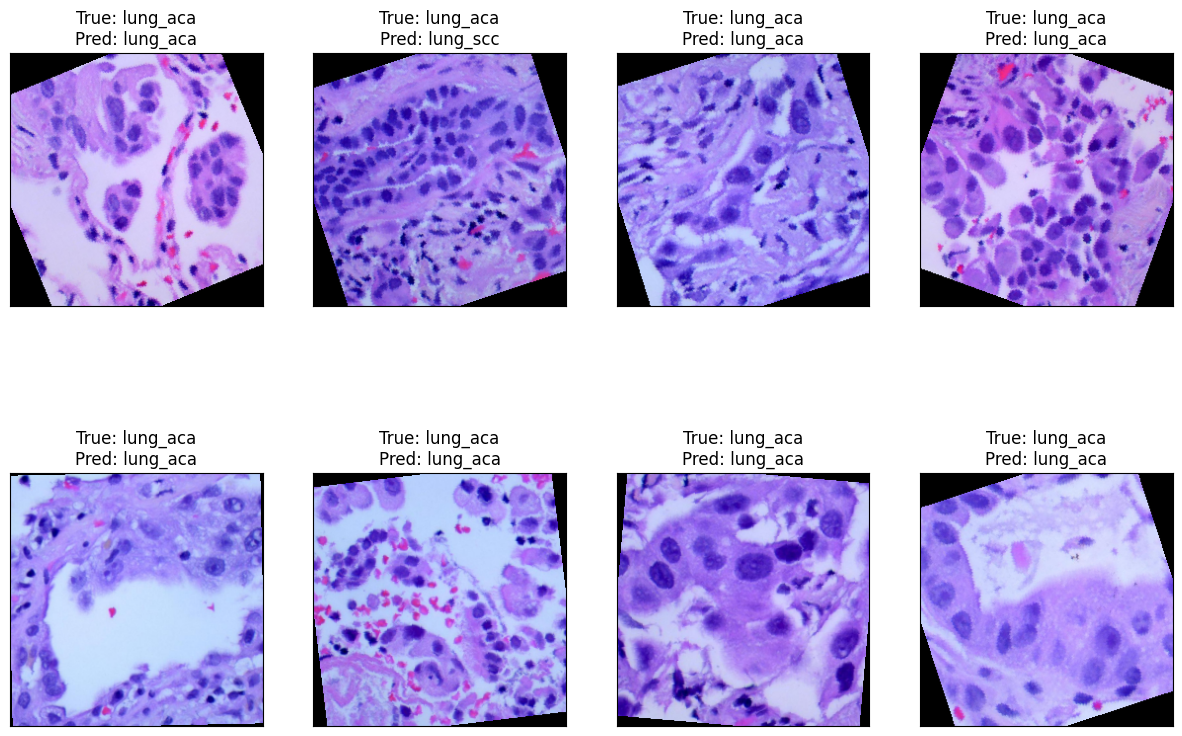

In [10]:
def visualize_predictions(model, test_loader, all_classes):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    images = images.cpu()
    fig = plt.figure(figsize=(15, 10))
    for idx in range(8): 
        ax = fig.add_subplot(2, 4, idx+1, xticks=[], yticks=[])
        img = images[idx].permute(1, 2, 0)  
        img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])  
        img = img.numpy().clip(0, 1)
        ax.imshow(img)
        ax.set_title(f"True: {all_classes[labels[idx]]}\nPred: {all_classes[predicted[idx]]}")

    plt.show()


visualize_predictions(model, test_loader, all_classes)

In [11]:
def test_model(model, test_loader):
    model.eval()
    test_correct = 0
    test_total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    
    test_accuracy = 100 * test_correct / test_total
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    return all_labels, all_preds

all_labels, all_preds = test_model(model, test_loader)

Test Accuracy: 97.56%


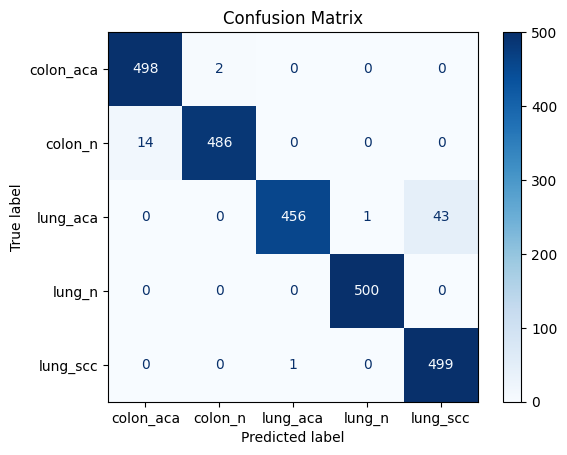

In [12]:
cm = confusion_matrix(all_labels, all_preds, labels=range(len(all_classes)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

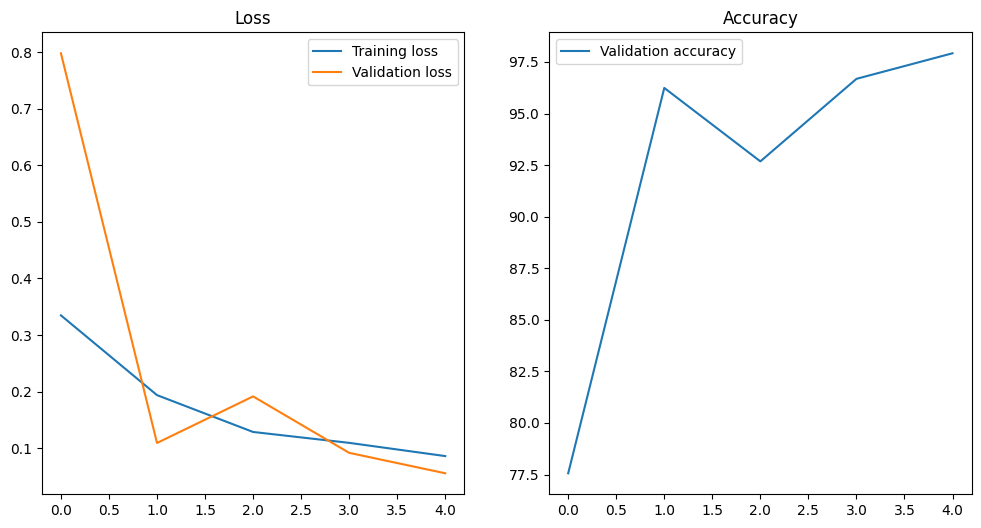

In [13]:
#train_losses, val_losses, val_accuracies = train_model(model, train_loader, val_loader, num_epochs=10)
# plotting the loss and accuracy
def plot_loss_accuracy(train_losses, val_losses, val_accuracies):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training loss')
    plt.plot(val_losses, label='Validation loss')
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Validation accuracy')
    plt.title("Accuracy")
    plt.legend()

    plt.show()
    
plot_loss_accuracy(train_losses, val_losses, val_accuracies)

### Saving the model to a file

In [14]:
# savving the model
save_path = './trainierte-modelle/cancer_cnn_model_2.pth'
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to ./trainierte-modelle/cancer_cnn_model_2.pth


# Grad Cam

Eine simple Implementation für eine Grad Cam um mein Modell erklärbar zu machen

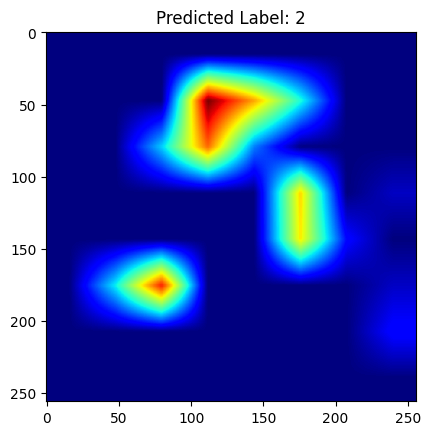

In [15]:
from pytorch_grad_cam import GradCAM

# Funktion zur Anwendung von Grad-CAM auf ein einzelnes Bild
def apply_grad_cam(model, image_tensor, target_layer, class_idx=None):
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0), targets=None)
    grayscale_cam = grayscale_cam[0, :]
    return grayscale_cam

# Funktion zur Visualisierung von Grad-CAM auf einem Test-Datenloader
def visualize_grad_cam(model, test_loader):
    model.eval()
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        target_layer = model.conv6
        cam_image = apply_grad_cam(model, images[0], target_layer)
        plt.imshow(cam_image, cmap='jet')
        plt.title(f"Predicted Label: {labels[0].item()}")
        plt.show()
        break
        
visualize_grad_cam(model, test_loader)
    

# Überlagerung mit dem Originalbild

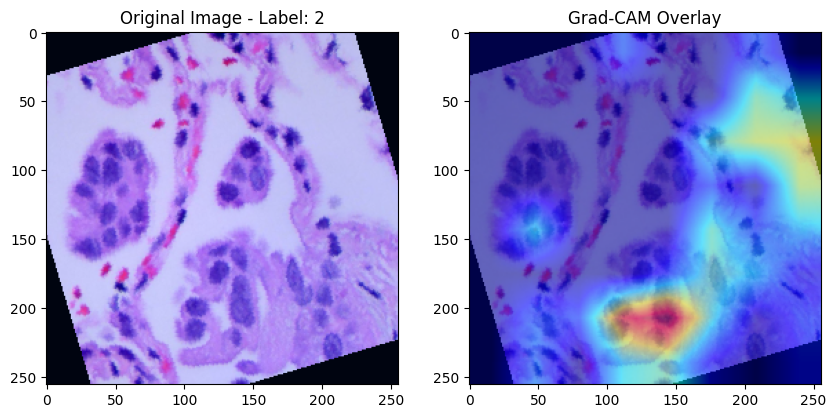

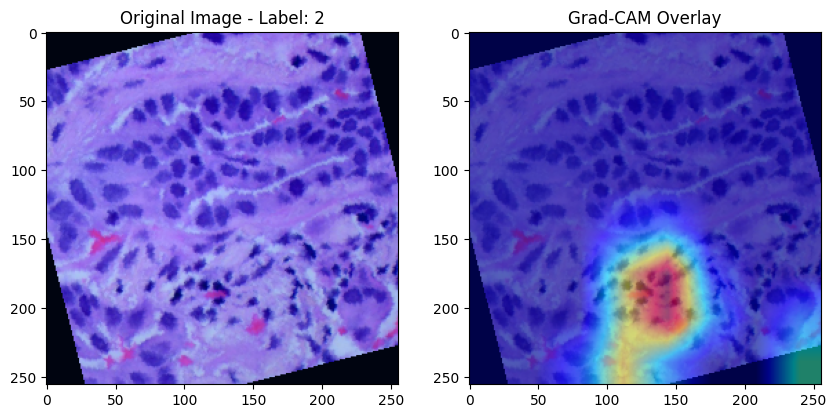

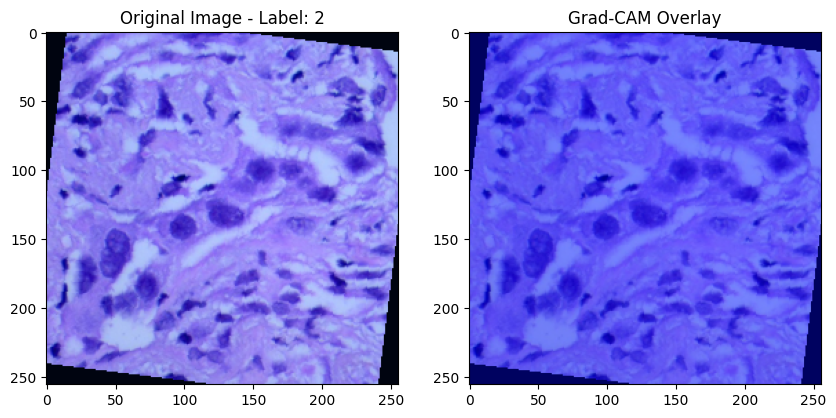

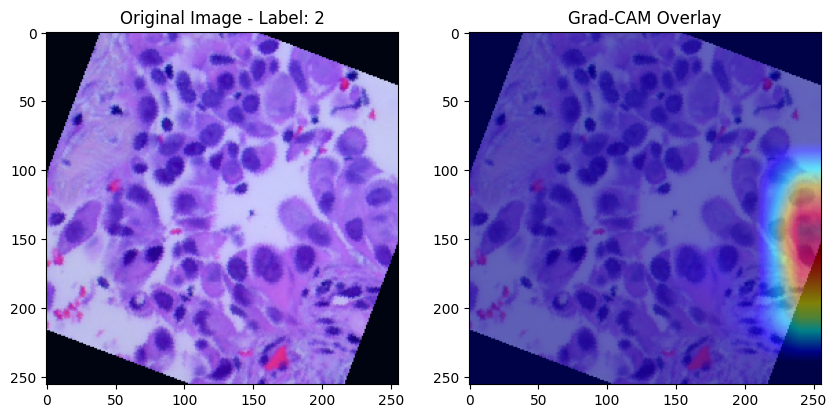

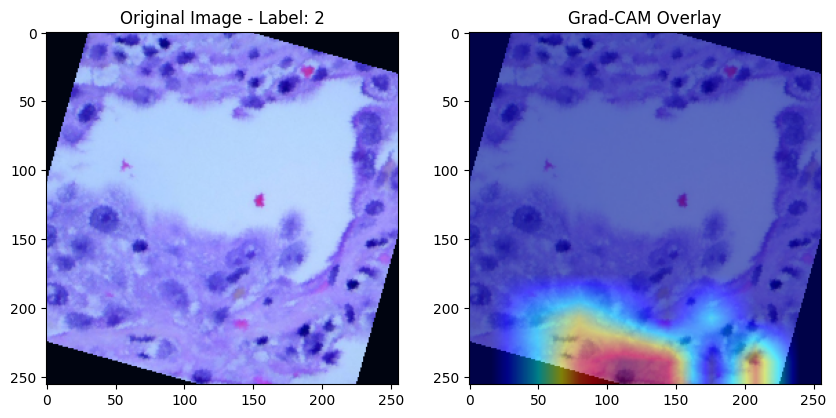

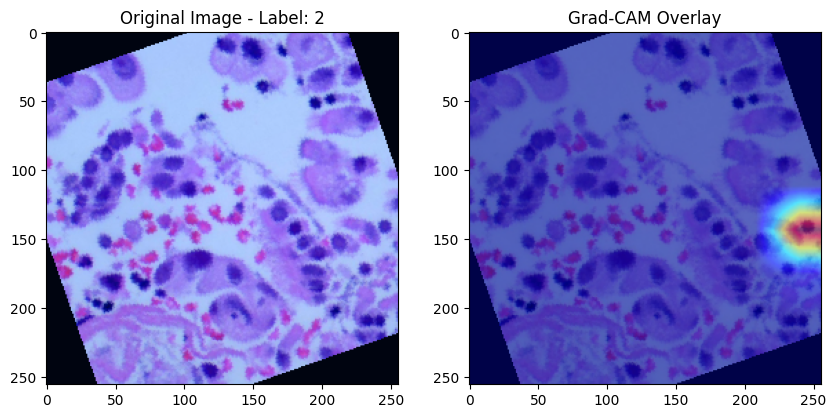

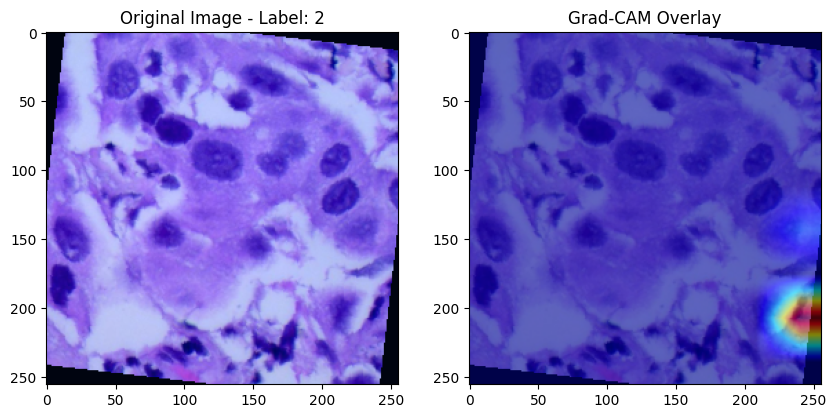

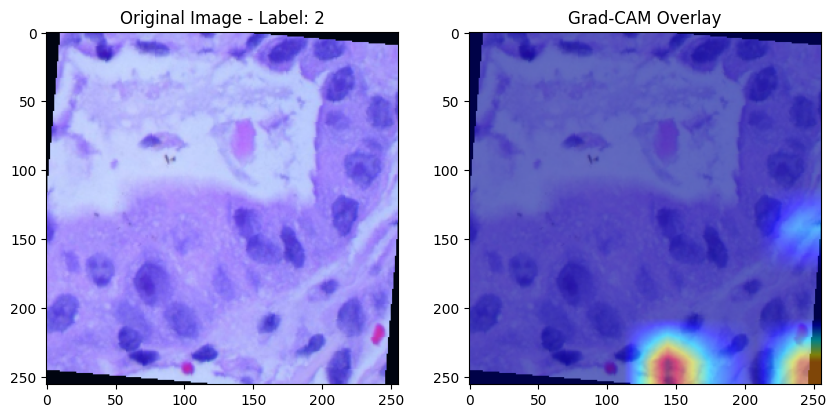

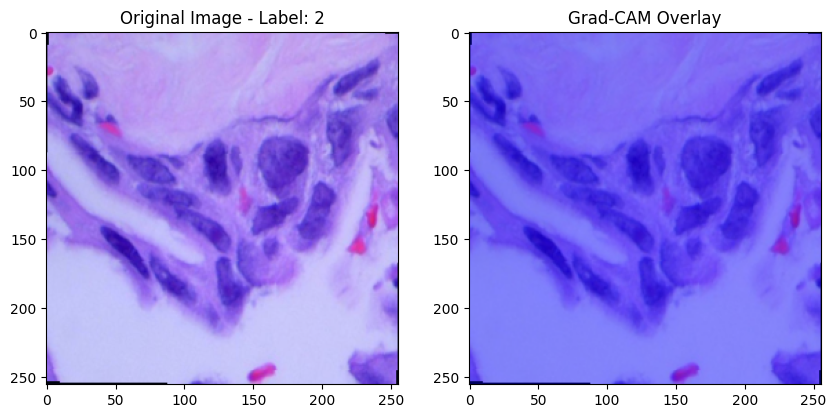

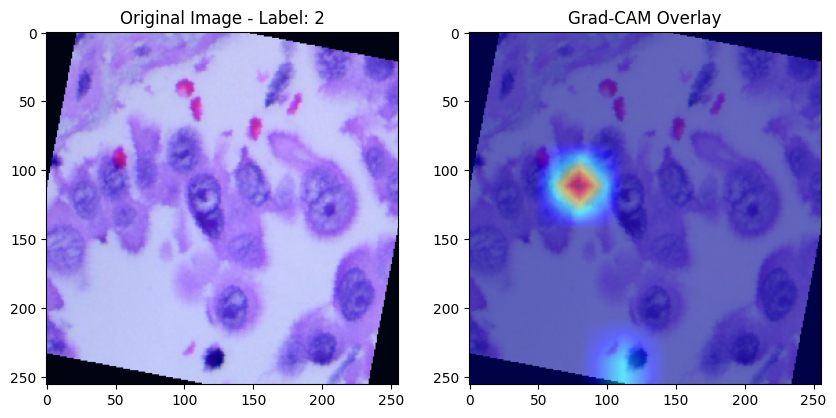

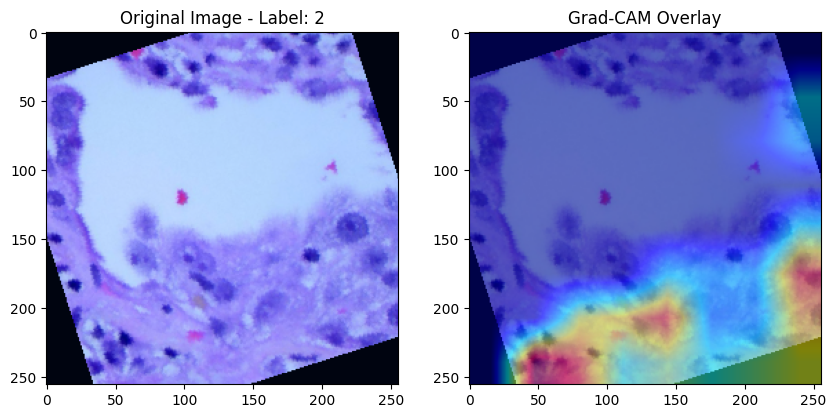

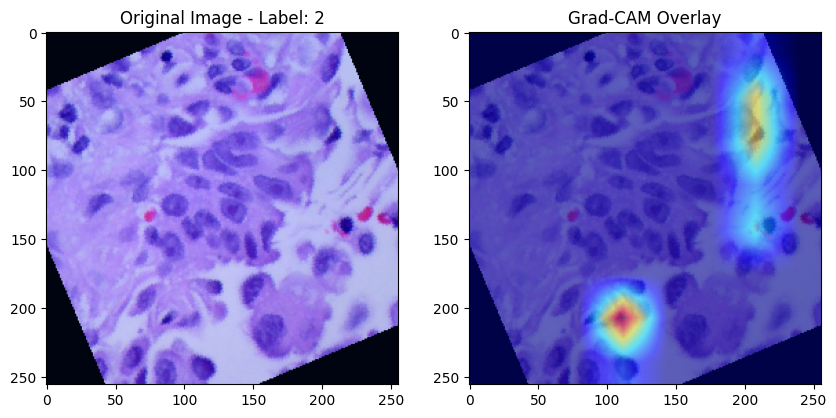

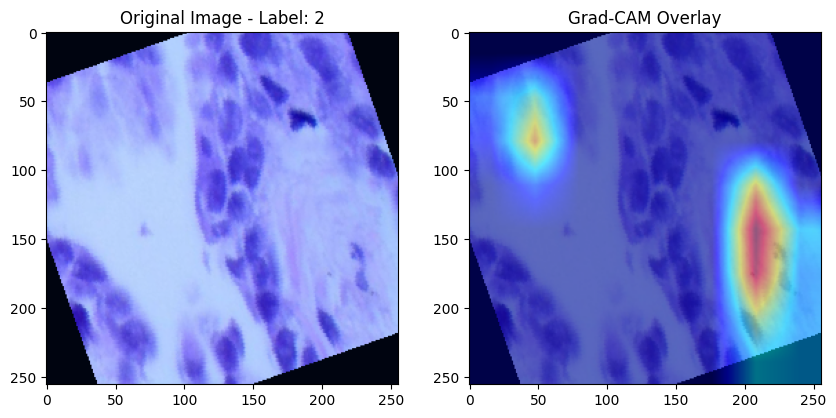

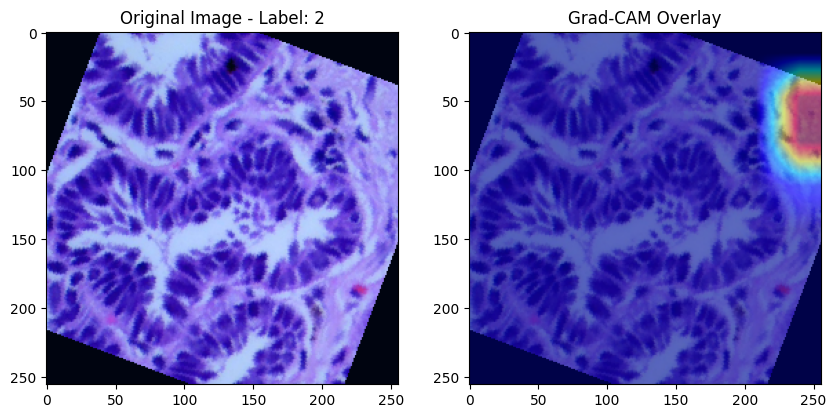

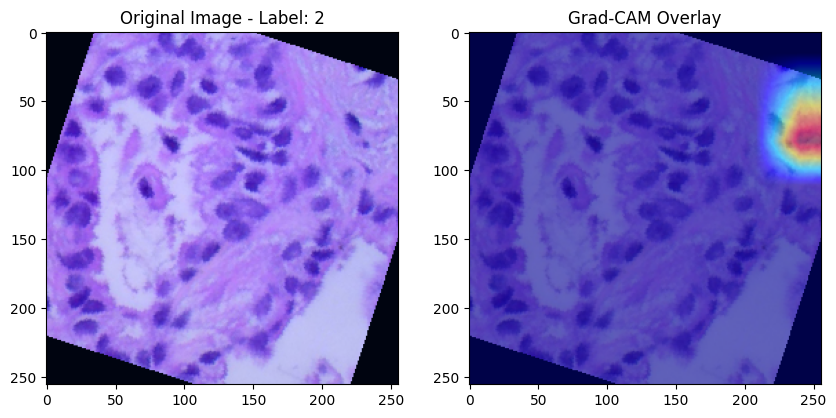

In [16]:
from pytorch_grad_cam.utils.image import show_cam_on_image

def visualize_gradcam(model, data_loader, target_layer):
    '''
    Visualize Grad-CAM for a batch of images from a data loader.
    Args:
        model (torch.nn.Module): The trained model to use for Grad-CAM.
        data_loader (torch.utils.data.DataLoader): DataLoader providing the images and labels.
        target_layer (torch.nn.Module): The target layer in the model for which Grad-CAM is computed.
    Returns:
        None: This function displays the original images and their corresponding Grad-CAM overlays.
    '''
    model.eval()
    images, labels = next(iter(data_loader))  
    images, labels = images.to(device), labels.to(device)
    
    cam = GradCAM(model=model, target_layers=[target_layer])
    
    for i in range(15):  
        input_tensor = images[i].unsqueeze(0) 
        grayscale_cam = cam(input_tensor=input_tensor)[0]
        image_rgb = images[i].permute(1, 2, 0).cpu().numpy()
        image_rgb = (image_rgb - image_rgb.min()) / (image_rgb.max() - image_rgb.min())
        
        cam_image = show_cam_on_image(image_rgb, grayscale_cam, use_rgb=True)
        
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(image_rgb)
        plt.title(f"Original Image - Label: {labels[i].item()}")
        
        plt.subplot(1, 2, 2)
        plt.imshow(cam_image)
        plt.title(f"Grad-CAM Overlay")
        plt.show()

visualize_gradcam(model, test_loader, target_layer=model.conv6) 

In [43]:
# Let's pick the first sample in the test set
sample_index = 0
sample_img, sample_label = test_dataset[sample_index]

# sample_img is a Tensor of shape [3, 256, 256] (assuming your transform outputs 3x256x256).
# We need to add a batch dimension for the model.
input_img = sample_img.unsqueeze(0).to(device)  # shape becomes [1, 3, 256, 256]

print(f"Sample Label: {sample_label}")

Sample Label: 2


In [44]:
model.eval()
with torch.no_grad():
    output = model(input_img)  # shape [1, num_classes]
    predicted_class = torch.argmax(output, dim=1).item()

print(f"Predicted Class: {predicted_class}")

Predicted Class: 2


# XAI

In [17]:
import shap

# 1. Hintergrund-Dataset auswählen
background_size = 100
background_dataset = Subset(train_dataset, range(background_size))
background_loader = DataLoader(background_dataset, batch_size=16, shuffle=True)
background = next(iter(background_loader))[0].to(device)

# 2. Eingabebild zur Erklärung auswählen
test_image, test_label = test_dataset[0]
test_image = test_image.unsqueeze(0).to(device)

# 3. DeepExplainer definieren
model.eval()
explainer = shap.DeepExplainer(model, background)

# 4. SHAP-Werte berechnen
shap_values = explainer.shap_values(test_image)

# 5. SHAP-Werte visualisieren
shap.image_plot(shap_values, test_image.cpu().numpy())


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NotImplementedError: The operator 'aten::max_unpool2d' is not currently implemented for the MPS device. If you want this op to be added in priority during the prototype phase of this feature, please comment on https://github.com/pytorch/pytorch/issues/77764. As a temporary fix, you can set the environment variable `PYTORCH_ENABLE_MPS_FALLBACK=1` to use the CPU as a fallback for this op. WARNING: this will be slower than running natively on MPS.

### Integrated Gradients

In [45]:
from captum.attr import IntegratedGradients
from captum.attr import visualization

def integrated_gradients(model, image, target_class, original_image):
    """
    Applies Integrated Gradients to the given model and image.

    Args:
        model (torch.nn.Module): Trained PyTorch model.
        image (torch.Tensor): Input tensor (single image with batch dimension).
        target_class (int): Target class index.
        original_image (torch.Tensor): Original image for visualization.

    Returns:
        None: Displays the visualization.
    """
    ig = IntegratedGradients(model)
    attributions, delta = ig.attribute(image, target=target_class, return_convergence_delta=True)
    visualization.visualize_image_attr(
        attributions.squeeze().cpu().detach().numpy(),
        original_image.squeeze().permute(1, 2, 0).numpy(),
        method="heat_map",
        sign="all",
        show_colorbar=True,
    )

In [47]:
# Suppose you have sample_img and input_img:
input_img = sample_img.unsqueeze(0).to(device)
input_img = input_img.to(torch.float32)  # Explicitly convert to float32

# Also convert your original image if you are passing it to Captum
original_img_for_vis = sample_img.unsqueeze(0).to(torch.float32).cpu()

# Now call integrated_gradients
integrated_gradients(
    model=model,
    image=input_img,
    target_class=predicted_class,
    original_image=original_img_for_vis
)

TypeError: Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.

### Saliency Maps

In [ ]:
from captum.attr import Saliency

def saliency_maps(model, image, target_class, original_image):
    """
    Applies Saliency Maps to the given model and image.

    Args:
        model (torch.nn.Module): Trained PyTorch model.
        image (torch.Tensor): Input tensor (single image with batch dimension).
        target_class (int): Target class index.
        original_image (torch.Tensor): Original image for visualization.

    Returns:
        None: Displays the visualization.
    """
    saliency = Saliency(model)
    attributions = saliency.attribute(image, target=target_class)
    visualization.visualize_image_attr(
        attributions.squeeze().cpu().detach().numpy(),
        original_image.squeeze().permute(1, 2, 0).numpy(),
        method="heat_map",
        sign="absolute_value",
        show_colorbar=True,
    )

### Deep Lift

In [ ]:
from captum.attr import DeepLift

def deep_lift(model, image, target_class, original_image):
    """
    Applies DeepLIFT to the given model and image.

    Args:
        model (torch.nn.Module): Trained PyTorch model.
        image (torch.Tensor): Input tensor (single image with batch dimension).
        target_class (int): Target class index.
        original_image (torch.Tensor): Original image for visualization.

    Returns:
        None: Displays the visualization.
    """
    deeplift = DeepLift(model)
    attributions = deeplift.attribute(image, target=target_class)
    visualization.visualize_image_attr(
        attributions.squeeze().cpu().detach().numpy(),
        original_image.squeeze().permute(1, 2, 0).numpy(),
        method="blended_heat_map",
        sign="all",
        show_colorbar=True,
    )

### Noise Tunnel (for Smoothing)

In [ ]:
from captum.attr import NoiseTunnel

def noise_tunnel_with_integrated_gradients(model, image, target_class, original_image):
    """
    Applies Noise Tunnel with Integrated Gradients to the given model and image.

    Args:
        model (torch.nn.Module): Trained PyTorch model.
        image (torch.Tensor): Input tensor (single image with batch dimension).
        target_class (int): Target class index.
        original_image (torch.Tensor): Original image for visualization.

    Returns:
        None: Displays the visualization.
    """
    ig = IntegratedGradients(model)
    noise_tunnel = NoiseTunnel(ig)
    attributions = noise_tunnel.attribute(image, target=target_class, nt_samples=10, nt_type='smoothgrad')
    visualization.visualize_image_attr(
        attributions.squeeze().cpu().detach().numpy(),
        original_image.squeeze().permute(1, 2, 0).numpy(),
        method="heat_map",
        sign="absolute_value",
        show_colorbar=True,
    )

### Feature Ablation

In [ ]:
from captum.attr import FeatureAblation

def feature_ablation(model, image, target_class):
    """
    Applies Feature Ablation to the given model and image.

    Args:
        model (torch.nn.Module): Trained PyTorch model.
        image (torch.Tensor): Input tensor (single image with batch dimension).
        target_class (int): Target class index.

    Returns:
        None: Prints the attributions.
    """
    ablator = FeatureAblation(model)
    attributions = ablator.attribute(image, target=target_class)
    print("Feature Ablation Attributions:", attributions)

### Shapley Value Sampling

In [ ]:
from captum.attr import ShapleyValueSampling

def shapley_value_sampling(model, image, target_class):
    """
    Applies Shapley Value Sampling to the given model and image.

    Args:
        model (torch.nn.Module): Trained PyTorch model.
        image (torch.Tensor): Input tensor (single image with batch dimension).
        target_class (int): Target class index.

    Returns:
        None: Prints the attributions.
    """
    shapley = ShapleyValueSampling(model)
    attributions = shapley.attribute(image, target=target_class)
    print("Shapley Value Sampling Attributions:", attributions)